### Spaceship Titanic

Predict which passengers are transported to an alternate dimension

https://www.kaggle.com/competitions/spaceship-titanic/overview

#### Overview

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

To help rescue crews and retrieve the lost passengers, you are challenged to predict which passengers were transported by the anomaly using records recovered from the spaceship’s damaged computer system.

Help save them and change history!

#### Data Description

**File and Data Field Descriptions**

* train.csv - Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
  * PassengerId - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
  * HomePlanet - The planet the passenger departed from, typically their planet of permanent residence.
  * CryoSleep - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
  * Cabin - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
  * Destination - The planet the passenger will be debarking to.
  * Age - The age of the passenger.
  * VIP - Whether the passenger has paid for special VIP service during the voyage.
  * RoomService, FoodCourt, ShoppingMall, Spa, VRDeck - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
  * Name - The first and last names of the passenger.
  * Transported - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.

* test.csv - Personal records for the remaining one-third (~4300) of the passengers, to be used as test data. Your task is to predict the value of Transported for the passengers in this set.
* sample_submission.csv - A submission file in the correct format.

  * PassengerId - Id for each passenger in the test set.
  * Transported - The target. For each passenger, predict either True or False.

#### Notebook Structure

1. Exploratory Data Analysis
2. Feature Engineering
3. Preprocessing Pipeline
4. Modeling & Evaluation
5. Business Hypothesis Testing
6. Kaggle Submission

### Setup

#### Install Packages

In [1]:
%%time
%pip install numpy pandas
%pip install seaborn matplotlib
%pip install scikit-learn xgboost lightgbm catboost
%pip install torch==2.8.0+cpu torchvision==0.23.0+cpu torchaudio==2.8.0+cpu \
    --index-url https://download.pytorch.org/whl/cpu

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cpu
Note: you may need to restart the kernel to use updated packages.
CPU times: total: 0 ns
Wall time: 4.88 s



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


#### Import Packages

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import torch

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

#### Download the Data

In [3]:
data_path = Path() / ".." / "data" / "Spaceship_Titanic"
submission_path = Path() / ".." / "submissions"

competition_name = "Spaceship Titanic"

print(f'spaceship_path: {data_path}')
print(f'submission_path: {submission_path}')

spaceship_path: ..\data\Spaceship_Titanic
submission_path: ..\submissions


In [4]:
# Read the data
def load_spaceship_data(filename, data_path=data_path):
    csv_path = os.path.join(data_path, filename)
    return pd.read_csv(csv_path)

# Save submission file
def save_submission(df, filename, submission_path=submission_path):
    if not os.path.exists(submission_path):
      os.makedirs(submission_path)

    csv_path = os.path.join(submission_path, filename)

    return df.to_csv(csv_path, index=False)

In [5]:
train_data = load_spaceship_data("train.csv")
test_data = load_spaceship_data("test.csv")

X = train_data.drop("Transported", axis=1)
y = train_data["Transported"]

### 1. Exploratory Data Analysis

In [6]:
print(f'Train shape: {train_data.shape}')
print(f'Test shape:  {test_data.shape}')
print(f'Columns in train but not test: {set(train_data.columns) - set(test_data.columns)}')

Train shape: (8693, 14)
Test shape:  (4277, 13)
Columns in train but not test: {'Transported'}


#### 1.1 Initial Data Inspection

In [ ]:
display(train_data.head(2))

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True


In [8]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB


In [9]:
train_data.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [10]:
import numpy as np

#Skewness of numerical features
skewness = train_data.select_dtypes(include=[np.number]).skew()
display(skewness)

Age              0.419097
RoomService      6.333014
FoodCourt        7.102228
ShoppingMall    12.627562
Spa              7.636020
VRDeck           7.819732
dtype: float64

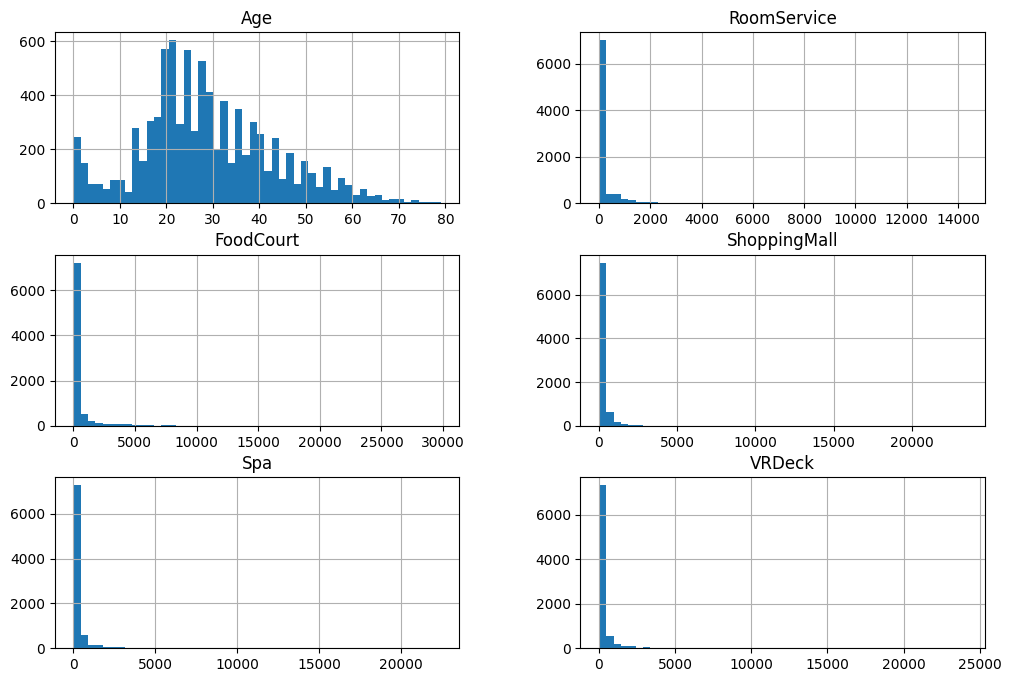

In [11]:
plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=12)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

train_data.hist(bins=50, figsize=(12, 8))
plt.show()

In [12]:
missing = train_data.isna().sum()
percent = (missing / len(train_data)) * 100

missing_df = pd.DataFrame({'Missing': missing, 'Percent': percent.round(2)})

display(missing_df)

,Missing,Percent
PassengerId,0,0.00
HomePlanet,201,2.31
CryoSleep,217,2.50
Cabin,199,2.29
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39


##### Observations

* Training set has 8693 rows and 14 columns (13 features + 1 target)
* Test set has 4277 rows and 13 columns (13 features and no Transported column)
* CryoSleep and VIP stored as object dtype desipte being boolean - this is because pandas cannot store NaN in a boolean column
* Services Spend (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck) is skewed right  with a signficant number of values = 0
* Cabin has structure Deck/Num/Side (e.g., B/0/P) — will parse into three separate features
* PassengerId has structure gggg_pp where gggg is group ID and pp is position within group — will engineer GroupSize and IsAlone features


#### 1.2 Target Variable Analysis

In [13]:
# Check the value counts for categorical attributes
print("Counts:")
print(train_data['Transported'].value_counts())

# Check the value counts for the target variable
print("\nProportion:")
print(train_data['Transported'].value_counts(normalize=True).round(4) * 100)

Counts:
Transported
True     4378
False    4315
Name: count, dtype: int64

Proportion:
Transported
True     50.36
False    49.64
Name: proportion, dtype: float64


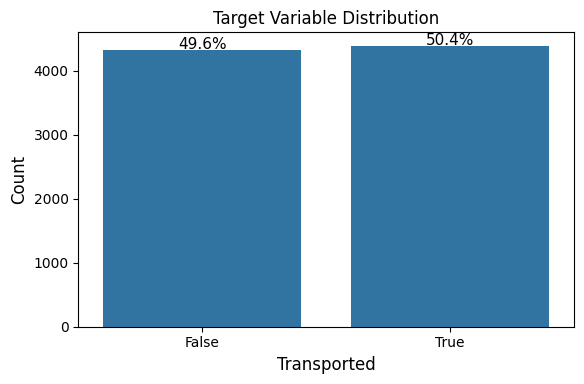

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x=y, data=X, ax=ax)

ax.set_title('Target Variable Distribution')
ax.set_xlabel('Transported')
ax.set_ylabel('Count')

# Add percentage labels on top of each bar
total = len(X)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha='center', fontsize=11)

plt.tight_layout()
plt.show()

##### Observations

* Classes are nearly balanced: X% Transported vs Y% Not Transported
* No need for class weighting or oversampling techniques

#### 1.3 Missing Values Analysis

In [15]:
missing = train_data.isna().sum()
percent = (missing / len(train_data)) * 100

missing_df = pd.DataFrame({'Missing': missing, 'Percent': percent.round(2)})

display(missing_df)

,Missing,Percent
PassengerId,0,0.00
HomePlanet,201,2.31
CryoSleep,217,2.50
Cabin,199,2.29
Destination,182,2.09
Age,179,2.06
VIP,203,2.34
RoomService,181,2.08
FoodCourt,183,2.11
ShoppingMall,208,2.39


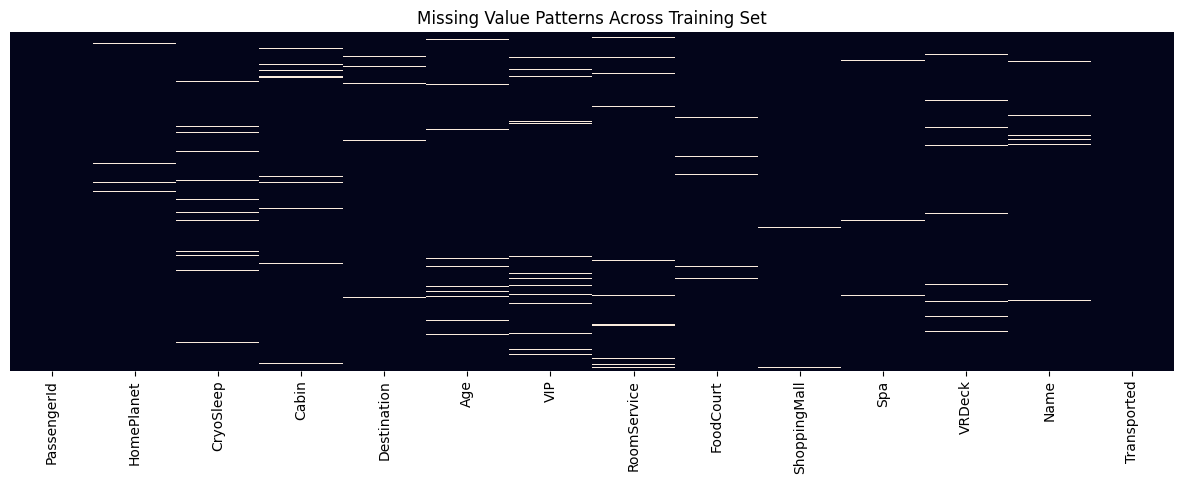

In [16]:
plt.figure(figsize=(12, 5))
sns.heatmap(train_data.isnull(), 
            cbar=False, 
            yticklabels=False)
plt.title('Missing Value Patterns Across Training Set')
plt.tight_layout()
plt.show()

In [17]:
for cols in train_data.columns:
    print(train_data.groupby(train_data[cols].isnull())['Transported'].mean())

PassengerId
False    0.503624
Name: Transported, dtype: float64
HomePlanet
False    0.503415
True     0.512438
Name: Transported, dtype: float64
CryoSleep
False    0.504011
True     0.488479
Name: Transported, dtype: float64
Cabin
False    0.503650
True     0.502513
Name: Transported, dtype: float64
Destination
False    0.503584
True     0.505495
Name: Transported, dtype: float64
Age
False    0.503641
True     0.502793
Name: Transported, dtype: float64
VIP
False    0.503416
True     0.512315
Name: Transported, dtype: float64
RoomService
False    0.504582
True     0.458564
Name: Transported, dtype: float64
FoodCourt
False    0.502820
True     0.540984
Name: Transported, dtype: float64
ShoppingMall
False    0.502534
True     0.548077
Name: Transported, dtype: float64
Spa
False    0.503760
True     0.497268
Name: Transported, dtype: float64
VRDeck
False    0.503233
True     0.521277
Name: Transported, dtype: float64
Name
False    0.503591
True     0.505000
Name: Transported, dtype: float6

##### Observations

* All columns except PassengerId and Transported have missing values, all within 2-3%
* Missing counts are all distinct, meaning missingness is scatterd independtly across columns rahter than entire rows being wiped
* Heatmap confirms no systematic vertical blocks — missingness appears largely random (consistent with MCAR or mild MAR)

#### 1.4 Categorical Features

In [18]:
train_data['PassengerId'].str.split('_').str[0].value_counts()

PassengerId
0984    8
4005    8
4256    8
4498    8
5133    8
       ..
9270    1
9274    1
9276    1
9278    1
9279    1
Name: count, Length: 6217, dtype: int64

In [19]:
train_data['PassengerId'].str.split('_').str[1].value_counts()

PassengerId
01    6217
02    1412
03     571
04     231
05     128
06      75
07      46
08      13
Name: count, dtype: int64

Text(0, 0.5, 'HomePlanet Count')

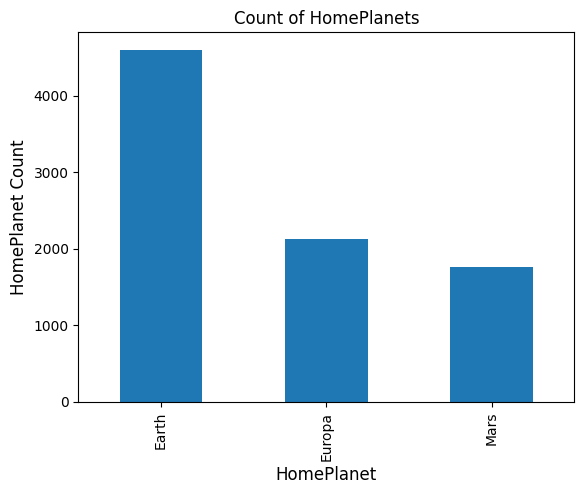

In [20]:
train_data["HomePlanet"].value_counts().plot(kind = 'bar')
plt.title('Count of HomePlanets')
plt.xlabel('HomePlanet')
plt.ylabel('HomePlanet Count')

In [21]:
# HomePlanet
train_data.groupby('HomePlanet')['Transported'].mean().sort_values(ascending=False)

HomePlanet
Europa    0.658846
Mars      0.523024
Earth     0.423946
Name: Transported, dtype: float64

In [22]:
train_data["Cabin"].str.split('/')

0          [B, 0, P]
1          [F, 0, S]
2          [A, 0, S]
3          [A, 0, S]
4          [F, 1, S]
            ...     
8688      [A, 98, P]
8689    [G, 1499, S]
8690    [G, 1500, S]
8691     [E, 608, S]
8692     [E, 608, S]
Name: Cabin, Length: 8693, dtype: object

In [23]:
# Deck
train_data["Cabin_Deck"] = train_data["Cabin"].str.split('/').str[0]

In [24]:
train_data["Cabin_Num"] = train_data["Cabin"].str.split('/').str[1]

In [25]:
train_data["Cabin_Side"] = train_data["Cabin"].str.split('/').str[2]

In [26]:
train_data.groupby('Cabin_Deck')['Transported'].mean().sort_values(ascending=False)

Cabin_Deck
B    0.734275
C    0.680054
G    0.516217
A    0.496094
F    0.439871
D    0.433054
E    0.357306
T    0.200000
Name: Transported, dtype: float64

In [27]:
# Relationship between HomePlanet and Deck, with Transported rate and passenger counts
result = (
    train_data
    .groupby(['HomePlanet', "Cabin_Deck"])
    .agg(
        Transported_Rate=('Transported', 'mean'),
        Passenger_Count=('PassengerId', 'count')
    )
    .sort_values('Transported_Rate', ascending=False)
)
display(result)

Transported_Rate  Passenger_Count
HomePlanet Cabin_Deck                                   
Europa     B                   0.733681              766
           C                   0.677112              734
Mars       F                   0.650450             1110
Europa     D                   0.586022              186
           E                   0.546875              128
Earth      G                   0.518014             2498
Europa     A                   0.496032              252
Earth      E                   0.372152              395
Mars       D                   0.333333              282
Earth      F                   0.292441             1614
Mars       E                   0.260606              330
Europa     T                   0.250000                4

In [28]:
train_data[train_data['HomePlanet'] == 'Mars'].groupby('Cabin_Side')['Transported'].mean()

Cabin_Side
P    0.500000
S    0.549161
Name: Transported, dtype: float64

In [29]:
train_data[train_data['HomePlanet'] == 'Mars'].groupby('Cabin_Deck')['Transported'].mean()

Cabin_Deck
D    0.333333
E    0.260606
F    0.650450
Name: Transported, dtype: float64

##### Observations

* Cabin parses clenly into Deck/Num/Side
    - Deck T has only 4 passengers
* Strong transport signal by Deck


#### 1.5 Numerical Features

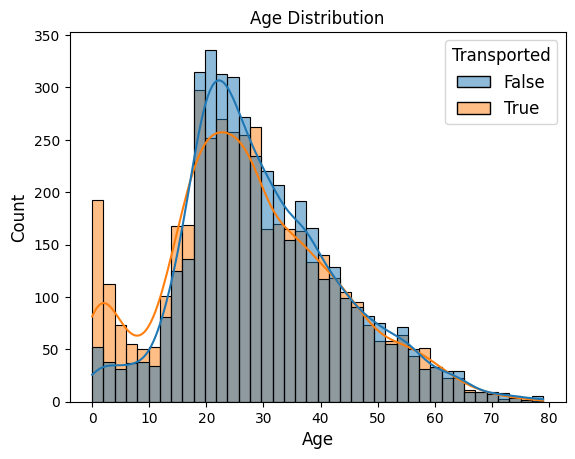

In [30]:
sns.histplot(data = X, x = "Age", kde = True, hue = y, bins = 40)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

In [31]:
train_data.groupby('CryoSleep')[['RoomService', 'FoodCourt', 'Spa']].mean()

,RoomService,FoodCourt,Spa
CryoSleep,,,
False,350.146772,713.004316,486.09294
True,0.000000,0.000000,0.00000


In [32]:
train_data.groupby('CryoSleep')['Transported'].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

##### Observations

* Notable spike at age 0 (infants) with ~67% transport rate — possibly related to higher CryoSleep rates for infants
* Transport rate is approximately 50/50 for ages 10+ meaning raw age has limited linear predictive power for adults
* KDE curves cross at approximately age 12-15, confirming the child threshold effect visually — under 12 skews transported, 12+ is approximately 50/50

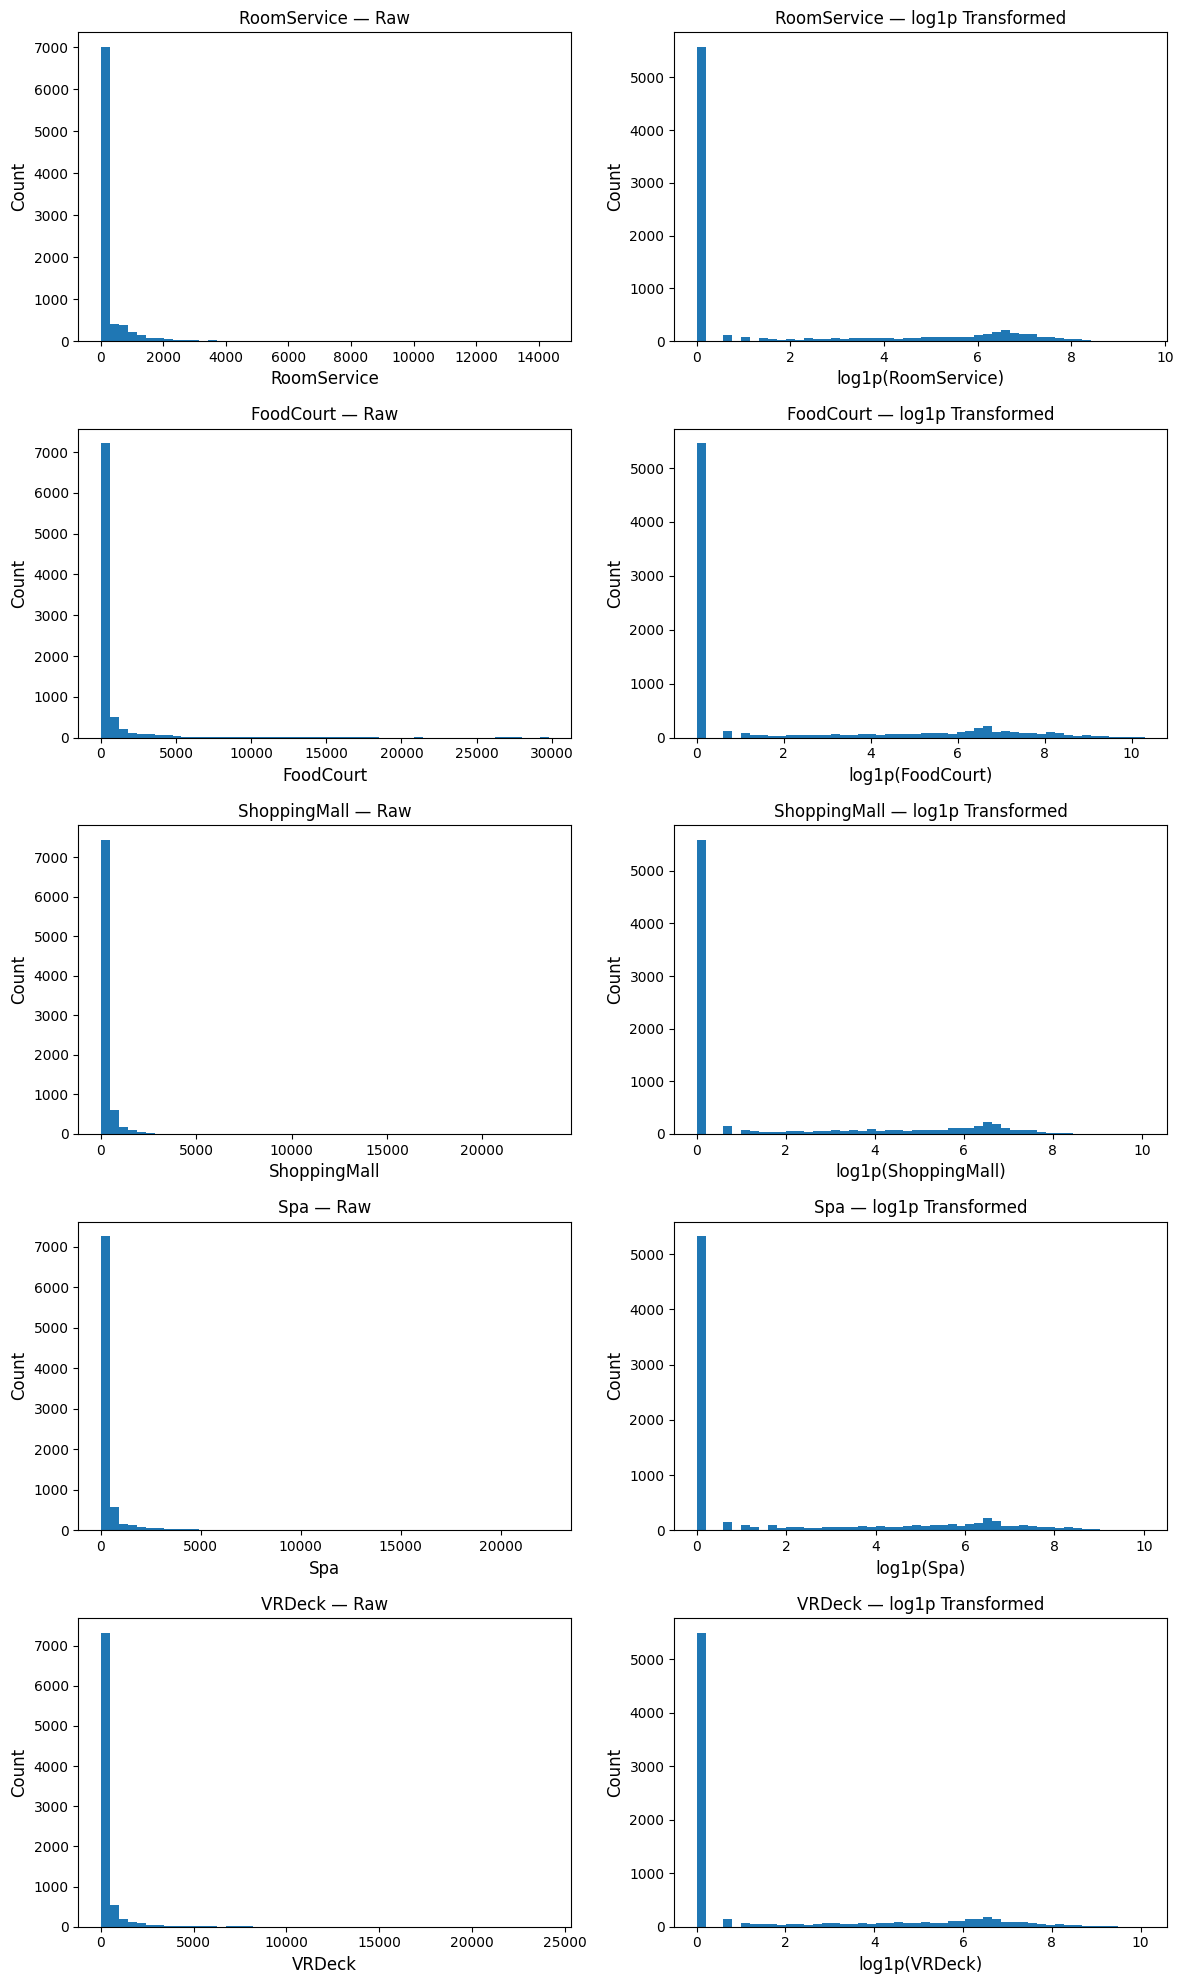

In [33]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(len(spend_cols), 2, figsize=(12, 20))

for i, col in enumerate(spend_cols):
    # Left plot — raw
    axes[i, 0].hist(train_data[col].dropna(), bins=50)
    axes[i, 0].set_title(f'{col} — Raw')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    
    # Right plot — log1p transformed
    axes[i, 1].hist(np.log1p(train_data[col].dropna()), bins=50)
    axes[i, 1].set_title(f'{col} — log1p Transformed')
    axes[i, 1].set_xlabel(f'log1p({col})')
    axes[i, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [34]:
# Skewness of numerical features (raw and log1p)
skew_raw = train_data.select_dtypes(include=[np.number]).skew()
skew_log1p = train_data.select_dtypes(include=[np.number]).apply(lambda x: np.log1p(x)).skew()

skew_df = pd.DataFrame({'skew_raw': skew_raw, 'skew_log1p': skew_log1p})
display(skew_df)

,skew_raw,skew_log1p
Age,0.419097,-2.241027
RoomService,6.333014,1.117736
FoodCourt,7.102228,1.110788
ShoppingMall,12.627562,1.201576
Spa,7.636020,1.090025
VRDeck,7.819732,1.160167


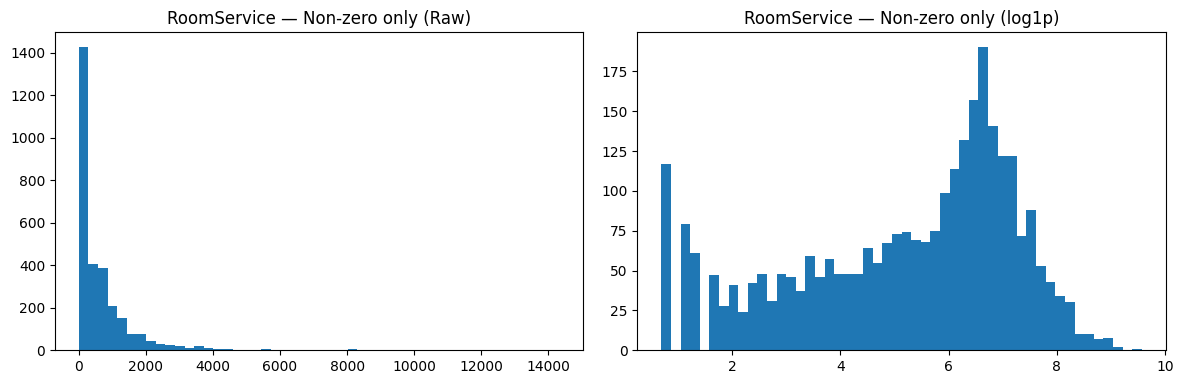

In [35]:
# Look at only passengers who actually spent something
spenders = train_data[train_data['RoomService'] > 0]['RoomService']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spenders, bins=50)
axes[0].set_title('RoomService — Non-zero only (Raw)')

axes[1].hist(np.log1p(spenders), bins=50)
axes[1].set_title('RoomService — Non-zero only (log1p)')

plt.tight_layout()
plt.show()

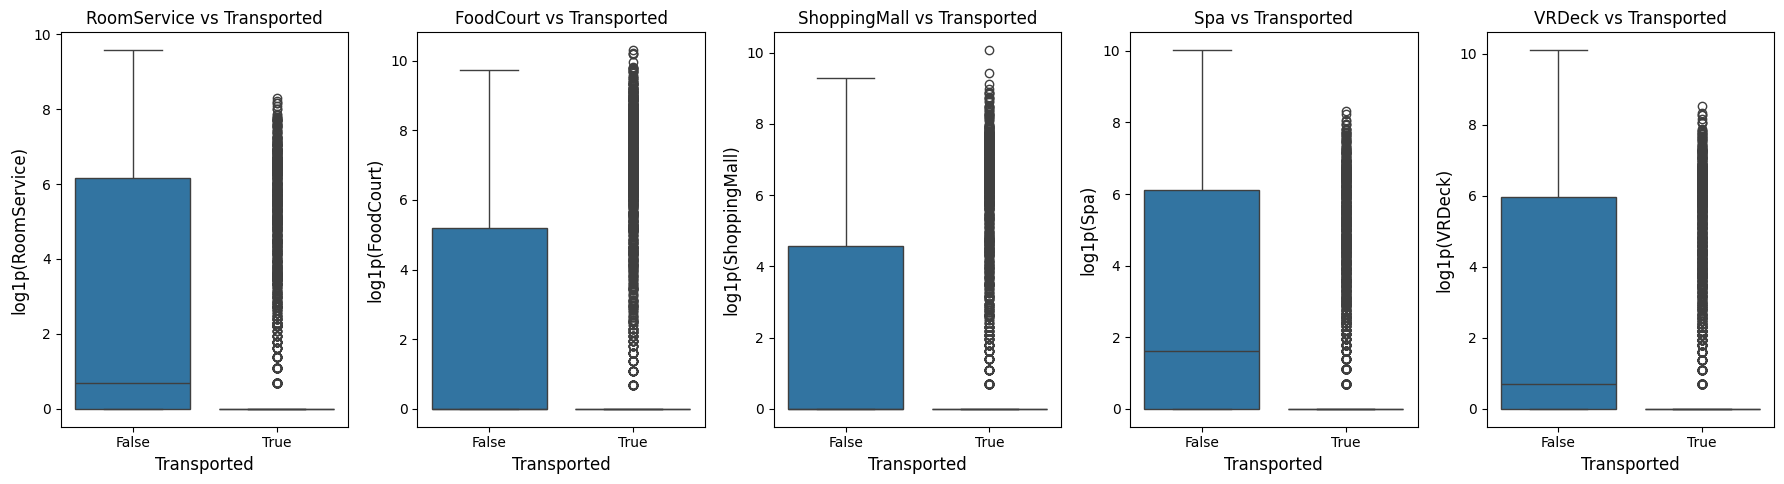

In [36]:
fig, axes = plt.subplots(1, len(spend_cols), figsize=(18, 5))

for i, col in enumerate(spend_cols):
    sns.boxplot(x=y, y=np.log1p(train_data[col]), data=train_data, ax=axes[i])
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_xlabel('Transported')
    axes[i].set_ylabel(f'log1p({col})')

plt.tight_layout()
plt.show()

##### Observations

* RoomService, Spa, VRDeck all show higher median spending for Transported=False — these are leisure amenities, active enjoyment of the ship correlates with not being transported
* FoodCourt and ShoppingMall show approximately equal medians across both classes — utility spending is not predictive
* Will engineer LeisureSpend and UtilitySpend separately in notebook 02 to capture this distinction

### 2. Feature Engineering

Feature Pipeline Description

All feature engineering is encapsulated in the FeatureEngineer class and applied identically to both train and test datasets, ensuring consistent transformations and preventing feature mismatch between splits.

**LogicalImputeTransformer (Minimal Data Repair)**

rule-based logical imputation using domain constraints

- Imputes missing Cabin values with Unknown/0/U
- Imputes missing Name values with Unknown Unknown
- Infers missing CryoSleep based on spending behavior:
    - TotalSpend == 0 → CryoSleep = 1
    - TotalSpend > 0 → CryoSleep = 0
- Imputes missing spending values with 0 for passengers identified as in CryoSleep

**FeatureEngineer**

- Group features
    - GroupId, GroupSize, IsAlone derived from PassengerId
- Cabin structure features
    - Deck, Cabin_Num, Cabin_Num_Binned, Side extracted from Cabin
- Identity-based features
    - LastName, FamilySize derived from shared surnames
- Age features
    - AgeBin: Child / Teen / YoungAdult / Adult / Senior
- Spending behavior features
    - TotalSpend, LuxurySpend, BasicSpend, SpendVariance
    - IsAwakeZeroSpender: active passengers with zero spending
- Binary indicators
    - CryoSleep, VIP retained as binary features for downstream encoding

**Log1pTransformer**

Applies log1p transformation to highly right-skewed numeric features (skewness > threshold) to reduce long-tail effects and improve model stability

- Applies log1p transformation to highly skewed numeric features (based on skewness threshold)
- Reduces long-tail effects in spending-related variables
- Improves stability for linear and gradient-based models



In [37]:
class LogicalImputeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        # Impute missing values for Cabin and Name with logical defaults
        X["Cabin"] = X["Cabin"].fillna("Unknown/0/U")
        X["Name"] = X["Name"].fillna("Unknown Unknown")

        spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

        # Rule 1: CryoSleep NaN + zero spending → CryoSleep = 1
        cond_null = X['CryoSleep'].isnull()
        cond_zero_spend = X[spend_cols].sum(axis=1) == 0
        rule1 = cond_null & cond_zero_spend
        X.loc[rule1, 'CryoSleep'] = 1

        # Rule 2: CryoSleep NaN + any spending > 0 → CryoSleep = 0
        cond_null = X['CryoSleep'].isnull()
        cond_spend = X[spend_cols].sum(axis=1) > 0
        rule2 = cond_null & cond_spend
        X.loc[rule2, 'CryoSleep'] = 0

        # Rule 3: CryoSleep = 1 + spending NaN → spending = 0
        cond_cryo_true = (X['CryoSleep'] == 1)
        for col in spend_cols:
            X.loc[cond_cryo_true, col] = X.loc[cond_cryo_true, col].fillna(0)

        return X
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_)

class FeatureEngineer(BaseEstimator, TransformerMixin):

    NUMERIC_FEATURES = [
        "Age",
        "GroupSize",
        "IsAlone", 
        "TotalSpend", 
        "LuxurySpend", 
        "BasicSpend", 
        "SpendVariance",
        "IsAwakeZeroSpender"
    ]
    ORDINAL_FEATURES = [
        "Cabin_Num_Binned", 
        "AgeBin"
    ]
    CATEGORICAL_FEATURES = [
        "Deck", 
        "Side", 
        "CryoSleep", 
        "VIP", 
        "HomePlanet", 
        "Destination"
    ]

    OUTPUT_FEATURES = NUMERIC_FEATURES + ORDINAL_FEATURES + CATEGORICAL_FEATURES

    def fit(self, X, y=None):

        cabin_split = X["Cabin"].str.split("/", expand=True)
        cabin_num = pd.to_numeric(cabin_split[1], errors="coerce")

        # store bin edges
        self.cabin_bins_ = pd.qcut(
            cabin_num,
            q=3,
            retbins=True,
            duplicates="drop"
        )[1]
        
        return self

    def transform(self, X):
        X = X.copy().reset_index(drop=True)

        # 2.1 PassengerId features
        # Extract GroupId and IndividualId from PassengerId and calculate GroupSize
        X["GroupId"] = X["PassengerId"].str[:4]
        X["IndividualId"] = X["PassengerId"].str[5:].astype(int)

        X["GroupSize"] = (
            X.groupby("GroupId")["IndividualId"]
            .transform("max")
            .to_numpy()
        )

        # 2.1 Cabin features
        # Create IsAlone feature based on GroupSize
        X["IsAlone"] = (X["GroupSize"] == 1).astype(int).to_numpy()

        # Split Cabin into Deck and Side
        cabin_split = X["Cabin"].str.split("/", expand=True)
        X["Deck"] = cabin_split[0].to_numpy()
        X["Cabin_Num"] =  pd.to_numeric(cabin_split[1], errors="coerce")
        X["Side"] = cabin_split[2].to_numpy()
        X["Cabin_Num_Binned"] = pd.cut(
            X["Cabin_Num"],
            bins=self.cabin_bins_,
            labels=["Low", "Mid", "High"][:len(self.cabin_bins_)-1],
            include_lowest=True
        )

        # 2.3 Name features
        X["LastName"] = X["Name"].str.split(" ").str[1]
        X["FamilySize"] = X.groupby("LastName")["LastName"].transform("count")

        # 2.4 Age features
        # Age bins
        X["AgeBin"] = pd.cut(X["Age"], bins = [0, 12, 17, 25, 65, 200],  labels = ['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'], include_lowest = True)

        #2.5 Spend features
        # Create CombinedServices as the sum of RoomService, FoodCourt, ShoppingMall, Spa, and VRDeck
        spend_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

        X["TotalSpend"] = X[spend_cols].sum(axis=1)
        X["BasicSpend"] = X[["FoodCourt", "ShoppingMall"]].sum(axis=1)
        X["LuxurySpend"] = X[["RoomService", "Spa", "VRDeck"]].sum(axis=1)
        X["SpendVariance"] = X[spend_cols].var(axis=1)
        X["IsAwakeZeroSpender"] = ((X['CryoSleep'] == False) & (X['TotalSpend'] == 0)).astype(int)

        return X[self.OUTPUT_FEATURES]

class Log1pTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = X.columns

        skew_vals = X.skew().abs()
        self.skewed_cols_ = skew_vals[skew_vals > 2.0].index.tolist()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in self.skewed_cols_:
            X[col] = np.log1p(np.clip(X[col], 0, None))

        return X.to_numpy()
    
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_)
    


In [38]:
# revert to the origin training set
train_raw = load_spaceship_data("train.csv")
test_raw = load_spaceship_data("test.csv")

X = train_raw.drop("Transported", axis=1)
y = train_raw["Transported"]

In [39]:
logical_imputer = LogicalImputeTransformer()

train_imputed = logical_imputer.fit_transform(train_raw)
test_imputed  = logical_imputer.transform(test_raw)

print("Missing values after logical imputation:")
# Calculate missing values for each
missing_raw = train_raw.isnull().sum()
missing_imputed = train_imputed.isnull().sum()
missing_change = missing_raw - missing_imputed

# Combine into a single DataFrame
missing_summary = pd.DataFrame({
    "Missing (train_raw)": missing_raw,
    "Missing (train_imputed)": missing_imputed,
    "Change": -missing_change
})

# Show only rows where at least one value is nonzero
display(missing_summary[(missing_summary != 0).any(axis=1)])

Missing values after logical imputation:


,Missing (train_raw),Missing (train_imputed),Change
HomePlanet,201,201,0
CryoSleep,217,0,-217
Cabin,199,0,-199
Destination,182,182,0
Age,179,179,0
VIP,203,203,0
RoomService,181,113,-68
FoodCourt,183,112,-71
ShoppingMall,208,109,-99
Spa,183,116,-67


In [40]:
engineer_features = FeatureEngineer()

engineer_features.fit(train_imputed)

train_engineered = pd.DataFrame(
    engineer_features.transform(train_imputed),
    columns=engineer_features.OUTPUT_FEATURES
)

test_engineered = pd.DataFrame(
    engineer_features.transform(test_imputed),
    columns=engineer_features.OUTPUT_FEATURES
)

print(f"Train columns: {train_engineered.shape[1]}")
print(f"Test columns:  {test_engineered.shape[1]}")
print(f"Column difference: {set(train_engineered.columns) - set(test_engineered.columns)}")

display(train_engineered.head(2))

Train columns: 16
Test columns:  16
Column difference: set()


,Age,GroupSize,IsAlone,TotalSpend,LuxurySpend,BasicSpend,SpendVariance,IsAwakeZeroSpender,Cabin_Num_Binned,AgeBin,Deck,Side,CryoSleep,VIP,HomePlanet,Destination
0,39.0,1,1,0.0,0.0,0.0,0.0,1,Low,Adult,B,P,False,False,Europa,TRAPPIST-1e
1,24.0,1,1,736.0,702.0,34.0,51896.2,0,Low,YoungAdult,F,S,False,False,Earth,TRAPPIST-1e


In [41]:
counts = train_engineered["IsAlone"].value_counts()
percent = train_engineered["IsAlone"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percent.round(2)
})

display(summary)

,Count,Percentage
IsAlone,,
1,4805,55.27
0,3888,44.73


In [42]:
counts = train_engineered["AgeBin"].value_counts()
percent = train_engineered["AgeBin"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percent.round(2)
})

display(summary)

,Count,Percentage
AgeBin,,
Adult,4534,53.25
YoungAdult,2351,27.61
Child,806,9.47
Teen,739,8.68
Senior,84,0.99


In [43]:
counts = train_engineered["GroupSize"].value_counts()
percent = train_engineered["GroupSize"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": counts,
    "Percentage": percent.round(2)
})

display(summary)

,Count,Percentage
GroupSize,,
1,4805,55.27
2,1682,19.35
3,1020,11.73
4,412,4.74
5,265,3.05
7,231,2.66
6,174,2.00
8,104,1.20


### 3. Preprocessing Pipeline

In [44]:
display(X.head(2))
display(y.head(2))

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

print(f'\nX_train type: {type(X_train)}')
print(f'y_train type: {type(y_train)}')
print(f'X_test type: {type(X_test)}')
print(f'y_test type: {type(y_test)}')

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines


0    False
1     True
Name: Transported, dtype: bool

X_train shape: (6954, 13)
y_train shape: (6954,)
X_test shape: (1739, 13)
y_test shape: (1739,)

X_train type: <class 'pandas.DataFrame'>
y_train type: <class 'pandas.Series'>
X_test type: <class 'pandas.DataFrame'>
y_test type: <class 'pandas.Series'>


In [45]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", Log1pTransformer()),
    ("scaler", StandardScaler())
])

# Pipeline for ordinal features
ord_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

onehot_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("to_str", FunctionTransformer(lambda X: X.astype(str), feature_names_out="one-to-one")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all
def make_preprocessing():
    return ColumnTransformer([
        ("num", num_pipeline, FeatureEngineer.NUMERIC_FEATURES),
        ("ord", ord_pipeline, FeatureEngineer.ORDINAL_FEATURES),
        ("onehot", onehot_pipeline, FeatureEngineer.CATEGORICAL_FEATURES),
    ])

preprocessing = make_preprocessing()
preprocessing.set_output(transform="pandas")

full_pipeline = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessing),
])

# Fit and transform
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

In [46]:
display(X_train.info())
display(X_train_prepared.info())

<class 'pandas.DataFrame'>
Index: 6954 entries, 3600 to 7925
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   6954 non-null   str    
 1   HomePlanet    6785 non-null   str    
 2   CryoSleep     6786 non-null   object 
 3   Cabin         6793 non-null   str    
 4   Destination   6801 non-null   str    
 5   Age           6815 non-null   float64
 6   VIP           6796 non-null   object 
 7   RoomService   6809 non-null   float64
 8   FoodCourt     6800 non-null   float64
 9   ShoppingMall  6785 non-null   float64
 10  Spa           6804 non-null   float64
 11  VRDeck        6810 non-null   float64
 12  Name          6795 non-null   str    
dtypes: float64(6), object(2), str(5)
memory usage: 760.6+ KB


None

<class 'pandas.DataFrame'>
RangeIndex: 6954 entries, 0 to 6953
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   num__Age                           6954 non-null   float64
 1   num__GroupSize                     6954 non-null   float64
 2   num__IsAlone                       6954 non-null   float64
 3   num__TotalSpend                    6954 non-null   float64
 4   num__LuxurySpend                   6954 non-null   float64
 5   num__BasicSpend                    6954 non-null   float64
 6   num__SpendVariance                 6954 non-null   float64
 7   num__IsAwakeZeroSpender            6954 non-null   float64
 8   ord__Cabin_Num_Binned              6954 non-null   float64
 9   ord__AgeBin                        6954 non-null   float64
 10  onehot__Deck_A                     6954 non-null   float64
 11  onehot__Deck_B                     6954 non-null   float64
 12  one

None

In [47]:
data_shape = {
    "X_train_prepared": X_train_prepared.shape,
    "X_test_prepared": X_test_prepared.shape
}

data_types = {
    "X_train_prepared": type(X_train_prepared),
    "X_test_prepared": type(X_test_prepared)
}

display(data_shape)
display(data_types)

display(X_train_prepared[:2])

{'X_train_prepared': (6954, 36), 'X_test_prepared': (1739, 36)}

{'X_train_prepared': pandas.DataFrame, 'X_test_prepared': pandas.DataFrame}

,num__Age,num__GroupSize,num__IsAlone,num__TotalSpend,num__LuxurySpend,num__BasicSpend,num__SpendVariance,num__IsAwakeZeroSpender,ord__Cabin_Num_Binned,ord__AgeBin,...,onehot__VIP_True,onehot__VIP_Unknown,onehot__HomePlanet_Earth,onehot__HomePlanet_Europa,onehot__HomePlanet_Mars,onehot__HomePlanet_Unknown,onehot__Destination_55 Cancri e,onehot__Destination_PSO J318.5-22,onehot__Destination_TRAPPIST-1e,onehot__Destination_Unknown
0,-1.996149,3.267803,-1.166743,-1.144932,-1.041025,-0.906126,-1.137812,3.899973,2.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.811703,-0.628126,0.857086,-1.144932,-1.041025,-0.906126,-1.137812,-0.256412,1.0,3.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [48]:
def get_feature_names(pipeline):
    return pipeline.named_steps["preprocessing"].get_feature_names_out()

display(get_feature_names(full_pipeline))

array(['num__Age', 'num__GroupSize', 'num__IsAlone', 'num__TotalSpend',
       'num__LuxurySpend', 'num__BasicSpend', 'num__SpendVariance',
       'num__IsAwakeZeroSpender', 'ord__Cabin_Num_Binned', 'ord__AgeBin',
       'onehot__Deck_A', 'onehot__Deck_B', 'onehot__Deck_C',
       'onehot__Deck_D', 'onehot__Deck_E', 'onehot__Deck_F',
       'onehot__Deck_G', 'onehot__Deck_T', 'onehot__Deck_Unknown',
       'onehot__Side_P', 'onehot__Side_S', 'onehot__Side_Unknown',
       'onehot__CryoSleep_False', 'onehot__CryoSleep_True',
       'onehot__CryoSleep_Unknown', 'onehot__VIP_False',
       'onehot__VIP_True', 'onehot__VIP_Unknown',
       'onehot__HomePlanet_Earth', 'onehot__HomePlanet_Europa',
       'onehot__HomePlanet_Mars', 'onehot__HomePlanet_Unknown',
       'onehot__Destination_55 Cancri e',
       'onehot__Destination_PSO J318.5-22',
       'onehot__Destination_TRAPPIST-1e', 'onehot__Destination_Unknown'],
      dtype=object)

In [49]:
def validate_pipeline(pipeline, X_sample):

    fe = pipeline.named_steps["feature_engineering"]
    pre = pipeline.named_steps["preprocessing"]

    # 1. FeatureEngineer contract
    X_fe = fe.transform(X_sample)
    expected = set(FeatureEngineer.OUTPUT_FEATURES)

    if set(X_fe.columns) != expected:
        raise ValueError("FeatureEngineer contract violated")

    # 2. Routing contract
    routed = set()
    for _, _, cols in pre.transformers_:
        routed.update(cols)

    if not expected.issubset(routed):
        raise ValueError("Routing contract violated")

    # 3. Final matrix validity
    X_out = pre.fit_transform(X_fe)

    if X_out.shape[1] == 0:
        raise ValueError("Empty feature matrix")

    return True

validate_pipeline(full_pipeline, X_train)

True

### 4. Modeling and Evaluation

- Preprocess the data once for all models to eliminate leakage

In [50]:
def make_pipeline(model):
    preprocessing = make_preprocessing()
    preprocessing.set_output(transform="pandas")

    return Pipeline([
        ("imputer", LogicalImputeTransformer()),
        ("feature_engineering", FeatureEngineer()),
        ("preprocessing", preprocessing),
        ("model", model)
    ])

#### Models

##### Logistic Regression

In [51]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = make_pipeline(LogisticRegression(max_iter=1000))
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('feature_engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [52]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = lr_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8004600345025877
              precision    recall  f1-score   support

       False       0.81      0.78      0.80       863
        True       0.79      0.82      0.80       876

    accuracy                           0.80      1739
   macro avg       0.80      0.80      0.80      1739
weighted avg       0.80      0.80      0.80      1739



#### Random Forest

In [53]:
rf_pipeline = make_pipeline(RandomForestClassifier(
                                n_estimators=300, 
                                random_state=42, 
                                n_jobs=-1
                                # verbose=2
                                )
                            )
                            
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('feature_engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [54]:
y_pred = rf_pipeline.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7947096032202415
              precision    recall  f1-score   support

       False       0.77      0.84      0.80       863
        True       0.83      0.75      0.79       876

    accuracy                           0.79      1739
   macro avg       0.80      0.80      0.79      1739
weighted avg       0.80      0.79      0.79      1739



In [55]:
pre = rf_pipeline.named_steps["preprocessing"]

feature_names = pre.get_feature_names_out()

importances = rf_pipeline.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(fi.head(20))

,feature,importance
4,num__LuxurySpend,0.185474
0,num__Age,0.137808
6,num__SpendVariance,0.112821
3,num__TotalSpend,0.111555
5,num__BasicSpend,0.104492
1,num__GroupSize,0.038744
8,ord__Cabin_Num_Binned,0.035800
25,onehot__CryoSleep_True,0.034971
24,onehot__CryoSleep_False,0.033650
9,ord__AgeBin,0.024517


##### Pytorch 

- Logistic Regression
- Classification Net

In [56]:
from torch.utils.data import DataLoader, TensorDataset

full_pipeline_pyt = Pipeline([
    ("feature_engineering", FeatureEngineer()),
    ("preprocessing", preprocessing)
])

X_train_prepared = full_pipeline_pyt.fit_transform(X_train)
X_test_prepared = full_pipeline_pyt.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_prepared.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_prepared.to_numpy(), dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

# Create datasets 
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [57]:
import torch.nn as nn

input_units = X_train_tensor.shape[1]

class LogisticRegressionModel(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()
        self.linear = nn.Linear(n_inputs, 1)

    def forward(self, x):
        return self.linear(x)
    
class ClassificationNet(nn.Module):
    def __init__(self, input_units=input_units, hidden_units=64, output_units=2):
        super().__init__()
        self.fc1 = nn.Linear(input_units, hidden_units)
        self.fc2 = nn.Linear(hidden_units, output_units)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

# Instantiate the model
model_torch_lr = LogisticRegressionModel(n_inputs=input_units)
model_nn = ClassificationNet(input_units=input_units, hidden_units=64, output_units=2)

y_train_bce = y_train_tensor.float().view(-1, 1)
y_train_ce  = y_train_tensor.long().view(-1)

In [58]:
print(model_torch_lr)
print(f'\n')
print(model_nn)
print(f'\n')
print(f'Model parameters: {list(model_torch_lr.parameters())}')
print(f'\n')
print(f'Model parameters: {list(model_nn.parameters())}')

LogisticRegressionModel(
  (linear): Linear(in_features=36, out_features=1, bias=True)
)


ClassificationNet(
  (fc1): Linear(in_features=36, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)


Model parameters: [Parameter containing:
tensor([[ 0.1042,  0.0122, -0.0355,  0.1143,  0.1257,  0.0374,  0.1202, -0.0730,
          0.1472, -0.0472,  0.0691,  0.0846,  0.1590, -0.0087, -0.0193,  0.1139,
         -0.0490,  0.0410,  0.1626,  0.1012,  0.0319,  0.0262, -0.1525,  0.0879,
          0.0402,  0.0809, -0.1631, -0.0090,  0.1555, -0.0429,  0.1302,  0.0958,
          0.1450,  0.1438,  0.0466, -0.1589]], requires_grad=True), Parameter containing:
tensor([-0.0505], requires_grad=True)]


Model parameters: [Parameter containing:
tensor([[-0.0967, -0.1318, -0.1074,  ..., -0.1451, -0.1352,  0.0036],
        [-0.0599,  0.1584,  0.0225,  ..., -0.0146,  0.0488, -0.0690],
        [ 0.0747, -0.0105,  0.0680,  ...,  0.1087, -0.1614, -0.0999],
        ...,
       

In [59]:
import torch.optim as optim

# Define the loss function and optimizer
criterion_lr = nn.BCEWithLogitsLoss()
optimizer_lr = torch.optim.SGD(
    model_torch_lr.parameters(), 
    lr = 0.05, 
    weight_decay=0.0001,
    momentum=0.9
)

criterion_nn = nn.CrossEntropyLoss()
optimizer_nn = optim.Adam(model_nn.parameters(), lr=0.001)

In [60]:
import torch
import matplotlib.pyplot as plt

def train_model(model, optimizer, criterion, train_loader, test_loader,
                epochs=1000, eval_every=50, task="binary"):

    loss_history = []
    train_acc_history = []
    test_acc_history = []
    eval_epochs = []

    best_test_acc = 0
    patience = 20
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):

        # =====================
        # TRAINING
        # =====================
        model.train()
        total_loss = 0

        for x, y in train_loader:

            optimizer.zero_grad()

            if task == "binary":
                y = y.float().view(-1, 1)
            else:
                y = y.long().view(-1)

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        loss_history.append(avg_loss)

        # =====================
        # EVALUATION
        # =====================
        if (epoch + 1) % eval_every == 0 or epoch == epochs - 1:

            model.eval()

            with torch.no_grad():

                # ---------------------
                # TRAIN ACC
                # ---------------------
                train_correct = 0
                train_total = 0

                for x, y in train_loader:

                    outputs = model(x)

                    if task == "binary":
                        probs = torch.sigmoid(outputs)
                        preds = (probs > 0.5).float().view(-1)
                    else:
                        preds = torch.argmax(outputs, dim=1)

                    train_correct += (preds == y.view(-1)).sum().item()
                    train_total += y.size(0)

                train_acc = train_correct / train_total

                # ---------------------
                # TEST ACC
                # ---------------------
                test_correct = 0
                test_total = 0

                for x, y in test_loader:

                    if task == "binary":
                        y = y.float().view(-1, 1)
                    else:
                        y = y.view(-1).long()

                    outputs = model(x)

                    if task == "binary":
                        probs = torch.sigmoid(outputs)
                        preds = (probs > 0.5).float().view(-1)
                    else:
                        preds = torch.argmax(outputs, dim=1)

                    test_correct += (preds == y.view(-1)).sum().item()
                    test_total += y.size(0)

                test_acc = test_correct / test_total

            train_acc_history.append(train_acc)
            test_acc_history.append(test_acc)
            eval_epochs.append(epoch + 1)

            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {avg_loss:.4f} | "
                f"Train Acc: {train_acc:.4f} | "
                f"Test Acc: {test_acc:.4f}"
            )

            if test_acc > best_test_acc:
                best_test_acc = test_acc
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    # =====================
    # PLOT
    # =====================
    plt.figure(figsize=(10, 6))

    plt.plot(loss_history, label="Loss")
    plt.plot(eval_epochs, train_acc_history, label="Train Accuracy")
    plt.plot(eval_epochs, test_acc_history, label="Test Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title("Training Progress")
    plt.legend()
    plt.grid(True)
    plt.show()

Epoch 10/1000 | Loss: 0.4651 | Train Acc: 0.7941 | Test Acc: 0.7953
Epoch 20/1000 | Loss: 0.4637 | Train Acc: 0.7918 | Test Acc: 0.7878
Epoch 30/1000 | Loss: 0.4643 | Train Acc: 0.7945 | Test Acc: 0.7959
Epoch 40/1000 | Loss: 0.4627 | Train Acc: 0.7931 | Test Acc: 0.7907
Epoch 50/1000 | Loss: 0.4642 | Train Acc: 0.7964 | Test Acc: 0.7982
Epoch 60/1000 | Loss: 0.4631 | Train Acc: 0.7934 | Test Acc: 0.7930
Epoch 70/1000 | Loss: 0.4641 | Train Acc: 0.7893 | Test Acc: 0.7890
Epoch 80/1000 | Loss: 0.4643 | Train Acc: 0.7952 | Test Acc: 0.7993
Epoch 90/1000 | Loss: 0.4644 | Train Acc: 0.7944 | Test Acc: 0.7976
Epoch 100/1000 | Loss: 0.4652 | Train Acc: 0.7948 | Test Acc: 0.7993
Epoch 110/1000 | Loss: 0.4632 | Train Acc: 0.7961 | Test Acc: 0.7959
Epoch 120/1000 | Loss: 0.4634 | Train Acc: 0.7948 | Test Acc: 0.7947
Epoch 130/1000 | Loss: 0.4629 | Train Acc: 0.7955 | Test Acc: 0.7941
Epoch 140/1000 | Loss: 0.4632 | Train Acc: 0.7959 | Test Acc: 0.7970
Epoch 150/1000 | Loss: 0.4630 | Train Acc: 

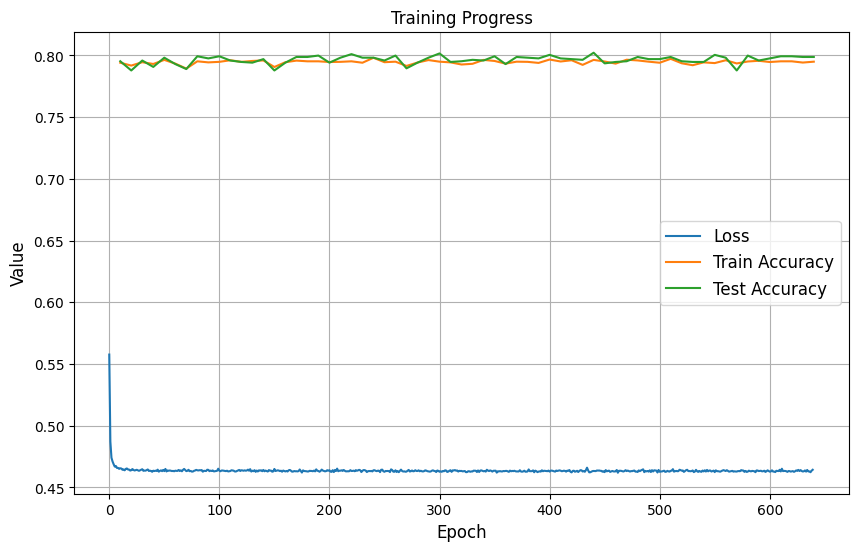

In [61]:
n_inputs = X_train_prepared.shape[1]
model_torch_lr = LogisticRegressionModel(n_inputs=n_inputs)
optimizer_lr = torch.optim.SGD(model_torch_lr.parameters(), lr=0.01, momentum=0.9)

train_model(
    model_torch_lr,
    optimizer_lr,
    nn.BCEWithLogitsLoss(),
    train_loader,
    test_loader,
    epochs=1000,
    eval_every=10,
    task="binary"
)

Epoch 20/400 | Loss: 0.4047 | Train Acc: 0.8073 | Test Acc: 0.8005
Epoch 40/400 | Loss: 0.3867 | Train Acc: 0.8234 | Test Acc: 0.7987
Epoch 60/400 | Loss: 0.3763 | Train Acc: 0.8253 | Test Acc: 0.8039
Epoch 80/400 | Loss: 0.3698 | Train Acc: 0.8292 | Test Acc: 0.8056
Epoch 100/400 | Loss: 0.3665 | Train Acc: 0.8348 | Test Acc: 0.8068
Epoch 120/400 | Loss: 0.3613 | Train Acc: 0.8371 | Test Acc: 0.8108
Epoch 140/400 | Loss: 0.3583 | Train Acc: 0.8365 | Test Acc: 0.7999
Epoch 160/400 | Loss: 0.3562 | Train Acc: 0.8385 | Test Acc: 0.8051
Epoch 180/400 | Loss: 0.3542 | Train Acc: 0.8405 | Test Acc: 0.8005
Epoch 200/400 | Loss: 0.3526 | Train Acc: 0.8394 | Test Acc: 0.8016
Epoch 220/400 | Loss: 0.3521 | Train Acc: 0.8399 | Test Acc: 0.8039
Epoch 240/400 | Loss: 0.3500 | Train Acc: 0.8375 | Test Acc: 0.8056
Epoch 260/400 | Loss: 0.3478 | Train Acc: 0.8430 | Test Acc: 0.8045
Epoch 280/400 | Loss: 0.3478 | Train Acc: 0.8434 | Test Acc: 0.8039
Epoch 300/400 | Loss: 0.3459 | Train Acc: 0.8440 | T

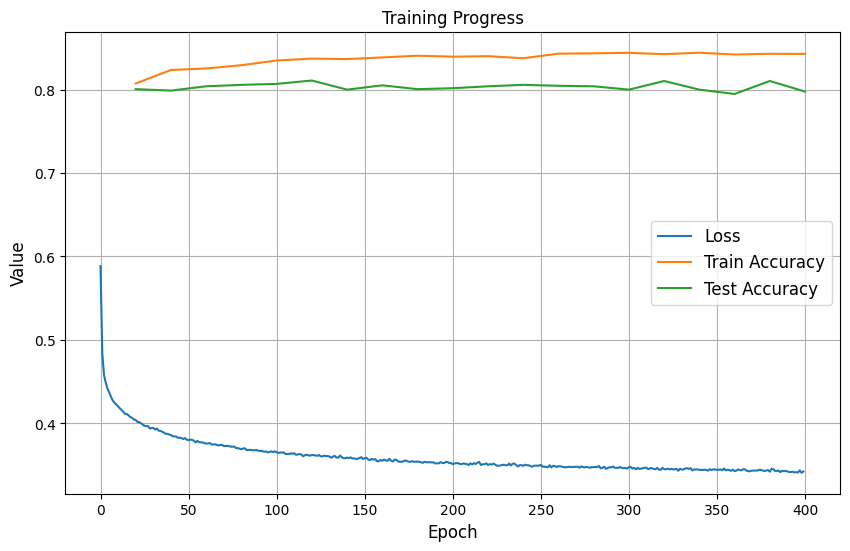

In [62]:
n_inputs = X_train_prepared.shape[1]

model_nn = ClassificationNet(
    input_units=n_inputs, 
    hidden_units=32, 
    output_units=2
    )

optimizer_nn = torch.optim.Adam(
    model_nn.parameters(), 
    lr=0.001,
    weight_decay=.0005
)

train_model(
    model_nn, 
    optimizer_nn, 
    nn.CrossEntropyLoss(),
    train_loader, 
    test_loader,
    epochs=400,
    eval_every=20,
    task="binary_softmax"
)

#### Model Evaluation

In [63]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)

    results = {
        "model": name,
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
    }

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
        results["roc_auc"] = roc_auc_score(y_test, probs)
    else:
        results["roc_auc"] = None

    return results

In [64]:
def make_models():
    return {
        "log_reg": make_pipeline(LogisticRegression(
                                    max_iter=1000
                                    )),
        "random_forest": make_pipeline(RandomForestClassifier(
                                            n_estimators=300, 
                                            random_state=42
                                            )),
        "hgb": make_pipeline(HistGradientBoostingClassifier(
                                max_depth=6,
                                learning_rate=0.05,
                                max_iter=300,
                                random_state=42
                          )),
        "xgb": make_pipeline(XGBClassifier(
                                n_estimators=500,
                                learning_rate=0.05,
                                max_depth=6,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                random_state=42,
                                n_jobs=-1
                            )),
        "lgbm": make_pipeline(LGBMClassifier(
                                n_estimators=500,
                                learning_rate=0.05,
                                num_leaves=31,
                                subsample=0.8,
                                colsample_bytree=0.8,
                                random_state=42
                            )),
    }

                                



In [65]:
sklearn_results = []

models = make_models()

for name, model in models.items():
    model.fit(X_train, y_train)
    sklearn_results.append(evaluate_model(name, model, X_test, y_test))



[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000187 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503595 -> initscore=0.014380
[LightGBM] [Info] Start training from score 0.014380


In [66]:
import pandas as pd

leaderboard = pd.DataFrame(sklearn_results)
leaderboard = leaderboard.sort_values("roc_auc", ascending=False)

display(leaderboard)

,model,accuracy,f1,roc_auc
2,hgb,0.816561,0.817818,0.903609
3,xgb,0.810811,0.810156,0.900639
4,lgbm,0.805635,0.805075,0.900541
1,random_forest,0.794710,0.786099,0.876923
0,log_reg,0.800460,0.804727,0.870740


In [67]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate_torch(model, loader, task="binary"):
    model.eval()

    preds = []
    targets = []
    probs_all = []

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)

            if task == "binary":
                probs = torch.sigmoid(outputs).view(-1)
                pred = (probs > 0.5).int()

                probs_all.extend(probs.numpy())

            else:
                probs = torch.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)

                # probability of positive class (class 1)
                probs_all.extend(probs[:, 1].numpy())

            preds.extend(pred.numpy())
            targets.extend(y.view(-1).numpy())

    results = {
        "accuracy": accuracy_score(targets, preds),
        "f1": f1_score(targets, preds),
    }

    # ROC-AUC always safe now
    try:
        results["roc_auc"] = roc_auc_score(targets, probs_all)
    except:
        results["roc_auc"] = None

    return results

In [68]:
torch_models = {
    "torch_logreg": {
        "model": model_torch_lr,
        "task": "binary"
    },
    "torch_nn": {
        "model": model_nn,
        "task": "binary_softmax"
    }
}

In [69]:
torch_results = []

for name, cfg in torch_models.items():
    model = cfg["model"]
    task = cfg["task"]

    res = evaluate_torch(model, test_loader, task=task)
    res["model"] = name
    torch_results.append(res)

In [70]:
all_results = sklearn_results + torch_results

leaderboard = pd.DataFrame(all_results)
leaderboard = leaderboard.sort_values("roc_auc", ascending=False)

display(leaderboard)

,model,accuracy,f1,roc_auc
2,hgb,0.816561,0.817818,0.903609
3,xgb,0.810811,0.810156,0.900639
4,lgbm,0.805635,0.805075,0.900541
6,torch_nn,0.797585,0.796296,0.891865
1,random_forest,0.794710,0.786099,0.876923
0,log_reg,0.800460,0.804727,0.870740
5,torch_logreg,0.798735,0.805556,0.869311


#### Fine-Tune Your Model

### Tuning

In [71]:
def tune_model(name, pipeline, param_distributions, X_train, y_train, X_test, y_test):

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=30,
        scoring="roc_auc",
        cv=5,
        verbose=0,   # keep silent
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    # -------------------------
    # TEST SET EVALUATION
    # -------------------------
    preds = best_model.predict(X_test)

    result = {
        "model": name,
        "cv_roc_auc": search.best_score_,
        "accuracy": accuracy_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "best_params": search.best_params_,
        "best_estimator": best_model
    }

    if hasattr(best_model, "predict_proba"):
        probs = best_model.predict_proba(X_test)[:, 1]
        result["roc_auc"] = roc_auc_score(y_test, probs)
    else:
        result["roc_auc"] = None

    return result

#### RandomForest

In [72]:
rf_pipeline = make_pipeline(
    RandomForestClassifier(random_state=42, n_jobs=-1)
)

rf_params = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5]
}

#### XGB

In [73]:
xgb_pipeline = make_pipeline(
    XGBClassifier(
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    )
)

xgb_params = {
    "model__n_estimators": [300, 500, 800],
    "model__max_depth": [3, 4, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

#### LightGBM

In [74]:
lgbm_pipeline = make_pipeline(
    LGBMClassifier(
        random_state=42
    )
)

lgbm_params = {
    "model__n_estimators": [300, 500, 800],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__max_depth": [-1, 5, 10],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_samples": [10, 20, 30]
}

#### HistGradientBoosting

In [75]:
hgb_pipeline = make_pipeline(
    HistGradientBoostingClassifier(
        random_state=42
    )
)

hgb_params = {
    "model__max_depth": [None, 3, 5, 10],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_iter": [200, 300, 500],
    "model__min_samples_leaf": [10, 20, 30],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [76]:
models_to_tune = {
    "rf_tuned": (rf_pipeline, rf_params),
    "xgb_tuned": (xgb_pipeline, xgb_params),
    "lgbm_tuned": (lgbm_pipeline, lgbm_params),
    "hgb_tuned": (hgb_pipeline, hgb_params)
}

#### Tuning and Results

In [77]:
tuned_results = []
tuned_models = {}

for name, (pipeline, params) in models_to_tune.items():

    print(f"\n{'='*60}")
    print(f"TUNING: {name}")
    print(f"{'='*60}")

    result = tune_model(
        name=name,
        pipeline=pipeline,
        param_distributions=params,
        X_train=X_train,
        y_train=y_train,
        X_test=X_test,
        y_test=y_test
    )

    # print immediate result
    print("Best CV Score:", result["cv_roc_auc"])
    print("Best Params:", result["best_params"])

    tuned_results.append(result)
    tuned_models[name] = result["best_estimator"]


TUNING: rf_tuned
Best CV Score: 0.8933690652273352
Best Params: {'model__n_estimators': 800, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 10}

TUNING: xgb_tuned
Best CV Score: 0.8965178426546426
Best Params: {'model__subsample': 0.8, 'model__n_estimators': 800, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}

TUNING: lgbm_tuned
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 3502, number of negative: 3452
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1175
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503595 -> initscore=0.014380
[LightGBM] [Info] Sta

In [78]:
import pandas as pd

all_results = sklearn_results + torch_results + tuned_results

leaderboard = pd.DataFrame(all_results)

display_cols = ["model", "accuracy", "f1", "roc_auc"]
leaderboard = leaderboard[display_cols].sort_values("roc_auc", ascending=False)

display(leaderboard)

,model,accuracy,f1,roc_auc
10,hgb_tuned,0.820587,0.821918,0.907661
8,xgb_tuned,0.815986,0.817143,0.905495
2,hgb,0.816561,0.817818,0.903609
9,lgbm_tuned,0.815986,0.816092,0.902378
3,xgb,0.810811,0.810156,0.900639
4,lgbm,0.805635,0.805075,0.900541
7,rf_tuned,0.802760,0.801849,0.899676
6,torch_nn,0.797585,0.796296,0.891865
1,random_forest,0.794710,0.786099,0.876923
0,log_reg,0.800460,0.804727,0.870740


### Blending

In [79]:
tuned_models = {}

for r in tuned_results:
    tuned_models[r["model"]] = r["best_estimator"]

xgb_proba = tuned_models["xgb_tuned"].predict_proba(X_test)[:, 1]
lgbm_proba = tuned_models["lgbm_tuned"].predict_proba(X_test)[:, 1]
hgb_proba = tuned_models["hgb_tuned"].predict_proba(X_test)[:, 1]

blend_proba = (xgb_proba + lgbm_proba + hgb_proba) / 3
blend_pred = (blend_proba >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

blend_result = {
    "model": "blend_xgb_lgbm_hgb",
    "accuracy": accuracy_score(y_test, blend_pred),
    "f1": f1_score(y_test, blend_pred),
    "roc_auc": roc_auc_score(y_test, blend_proba)
}

In [80]:
all_results = sklearn_results + torch_results + tuned_results + [blend_result]

leaderboard = pd.DataFrame(all_results)

display_cols = ["model", "accuracy", "f1", "roc_auc"]
leaderboard = leaderboard[display_cols].sort_values("roc_auc", ascending=False)

display(leaderboard)

,model,accuracy,f1,roc_auc
10,hgb_tuned,0.820587,0.821918,0.907661
11,blend_xgb_lgbm_hgb,0.819436,0.820571,0.906391
8,xgb_tuned,0.815986,0.817143,0.905495
2,hgb,0.816561,0.817818,0.903609
9,lgbm_tuned,0.815986,0.816092,0.902378
3,xgb,0.810811,0.810156,0.900639
4,lgbm,0.805635,0.805075,0.900541
7,rf_tuned,0.802760,0.801849,0.899676
6,torch_nn,0.797585,0.796296,0.891865
1,random_forest,0.794710,0.786099,0.876923


### Stacking

In [81]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

base_models = [
    ("xgb", tuned_models["xgb_tuned"]),
    ("lgbm", tuned_models["lgbm_tuned"]),
    ("hgb", tuned_models["hgb_tuned"])
]

meta_model = LogisticRegression()

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    stack_method="predict_proba",  # important for ROC-AUC
    passthrough=False,             # keep it clean first
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)[:, 1]

stack_result = {
    "model": "stack_xgb_lgbm_hgb",
    "accuracy": accuracy_score(y_test, stack_pred),
    "f1": f1_score(y_test, stack_pred),
    "roc_auc": roc_auc_score(y_test, stack_proba)
}

In [82]:
all_results.append(stack_result)

leaderboard = pd.DataFrame(all_results)
display_cols = ["model", "accuracy", "f1", "roc_auc"]
leaderboard = leaderboard[display_cols].sort_values("roc_auc", ascending=False)

display(leaderboard)

,model,accuracy,f1,roc_auc
10,hgb_tuned,0.820587,0.821918,0.907661
12,stack_xgb_lgbm_hgb,0.820587,0.822121,0.906394
11,blend_xgb_lgbm_hgb,0.819436,0.820571,0.906391
8,xgb_tuned,0.815986,0.817143,0.905495
2,hgb,0.816561,0.817818,0.903609
9,lgbm_tuned,0.815986,0.816092,0.902378
3,xgb,0.810811,0.810156,0.900639
4,lgbm,0.805635,0.805075,0.900541
7,rf_tuned,0.802760,0.801849,0.899676
6,torch_nn,0.797585,0.796296,0.891865


## Submission

In [83]:
X_test_sub = load_spaceship_data("test.csv")

display(X_test_sub.head(2))

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers


In [84]:
best_hgb = tuned_models["hgb_tuned"]

y_proba = best_hgb.predict_proba(X_test_sub)[:, 1]
y_pred = best_hgb.predict(X_test_sub)

In [85]:
submission_df = pd.DataFrame({
    "PassengerId": X_test_sub["PassengerId"],
    "Transported": y_pred.astype(bool)
})

submission_df.sort_values("PassengerId", inplace=True)

In [86]:
save_submission(submission_df,"submission.csv")
y_test_pred = best_hgb.predict(X_test_sub)